In [ ]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from sktime.forecasting.tbats import TBATS
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

warnings.filterwarnings('ignore', category=FutureWarning)

/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/

In [2]:
sales = pd.read_csv('pedidos.csv', sep=';')

In [3]:
df_count = sales[['account_id', 'sales_channel_id']].value_counts()
df_count = pd.DataFrame(df_count).reset_index()

In [4]:
ALL_SALES_CHANNELS = True
LOOKBACK = 3
SEASONAL_PERIODS = [24, 24*7]
COVERAGE = 0.2
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [5]:
# ####
# LOOKBACK = 3
# SEASONAL_PERIODS = (24, 24*7)
# COVERAGE = 0.35
# END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
# TEST_SIZE = 24

# OOT_DATE = END_DATE + timedelta(hours=13)
# ####

In [6]:
OOT_DATE = START_DATE + timedelta(hours=23)

In [7]:
OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [8]:
oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
df_oot = pd.DataFrame(index=oot_dates)

In [9]:
# ####
# sales.drop('sales_channel_id', axis=1, inplace=True)
# df = sales['account_id'].value_counts()
# df = pd.DataFrame(df).reset_index()

# df
# ####

Processing account_id: b009c05b-326e-4ebe-988c-8d2229ec3a4c, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 859.554
train MAE:  589.582
test RMSE: 412.510
test MAE:  312.995


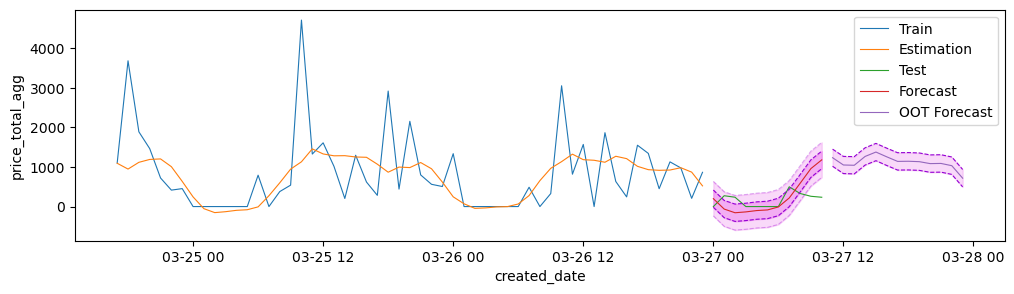

Processing column: n_orders
train RMSE: 1.790
train MAE:  1.296
test RMSE: 1.057
test MAE:  0.746


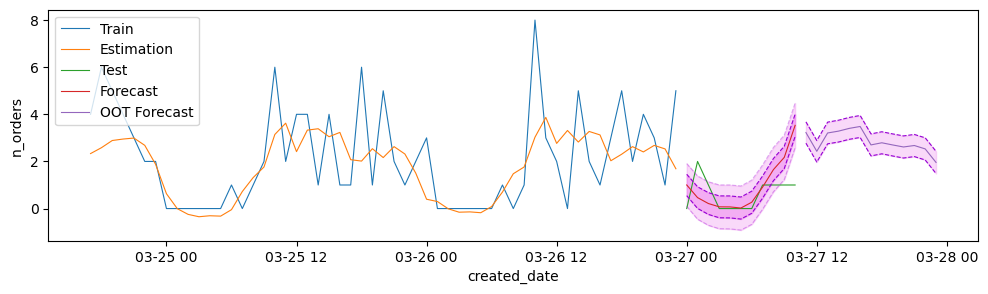

Processing account_id: d639773a-df2c-421e-ac87-6918a754572f, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 1223.772
train MAE:  532.995
test RMSE: 1128.507
test MAE:  1000.527


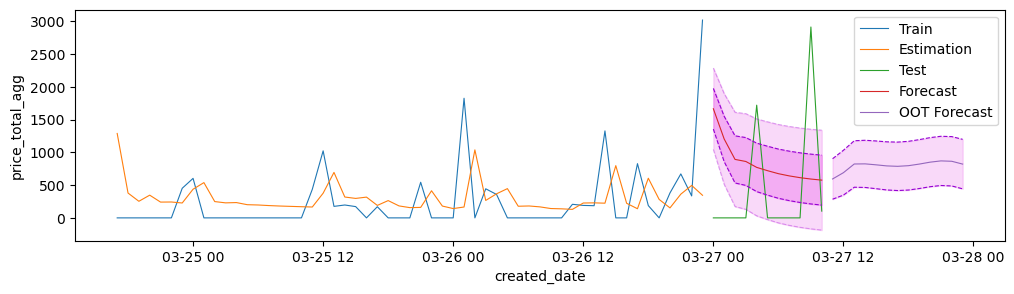

Processing column: n_orders
train RMSE: 6.481
train MAE:  2.061
test RMSE: 1.739
test MAE:  1.526


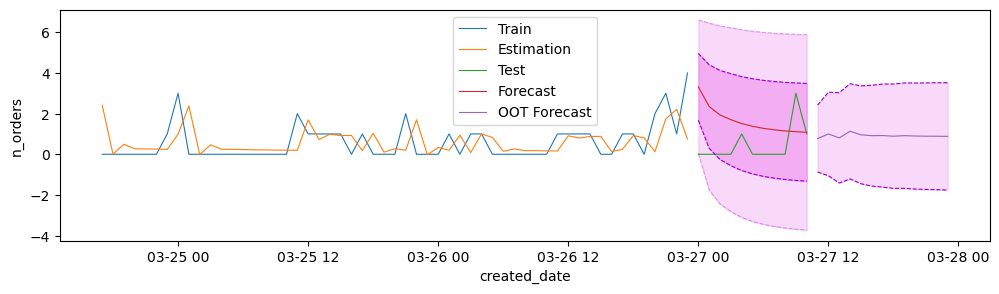

Processing account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 12643.340
train MAE:  7989.974
test RMSE: 6702.131
test MAE:  6517.178


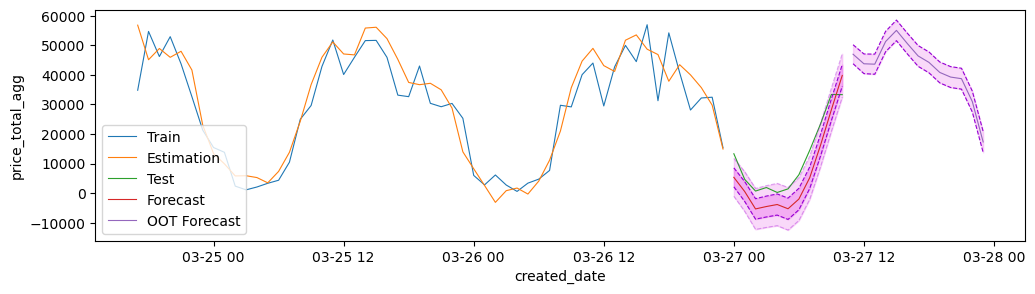

Processing column: n_orders
train RMSE: 31.445
train MAE:  16.862
test RMSE: 11.900
test MAE:  7.973


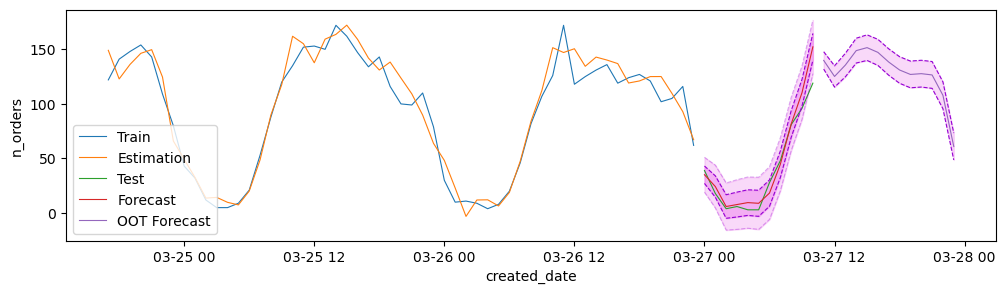

Processing account_id: adc6fb62-09e7-44fd-a619-f787ecfd140b, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 691.255
train MAE:  500.068
test RMSE: 629.662
test MAE:  509.763


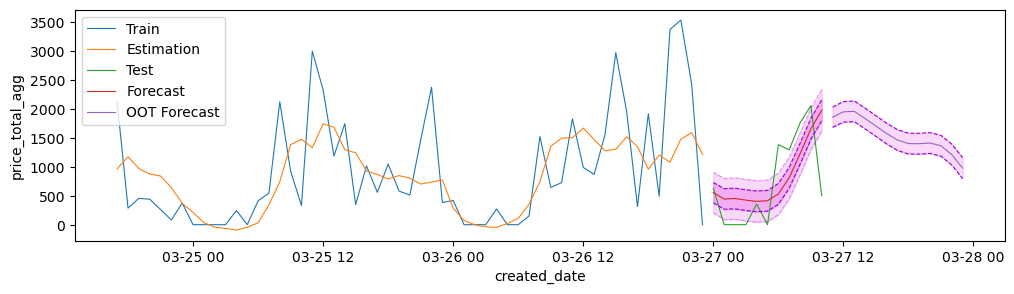

Processing column: n_orders
train RMSE: 2.136
train MAE:  1.559
test RMSE: 2.160
test MAE:  1.562


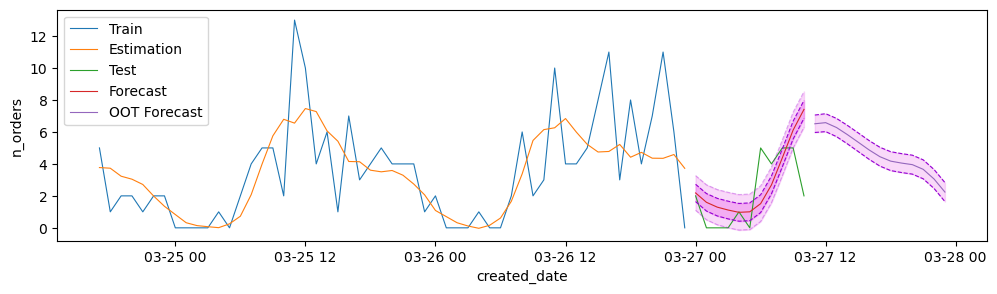

Processing account_id: ca35e88d-d191-4722-b90c-92f4a249869b, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 776.052
train MAE:  485.244
test RMSE: 526.503
test MAE:  307.647


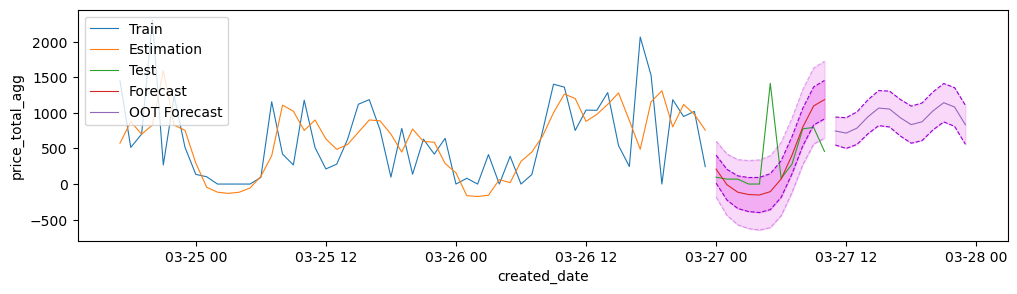

Processing column: n_orders
train RMSE: 3.205
train MAE:  2.036
test RMSE: 2.187
test MAE:  1.610


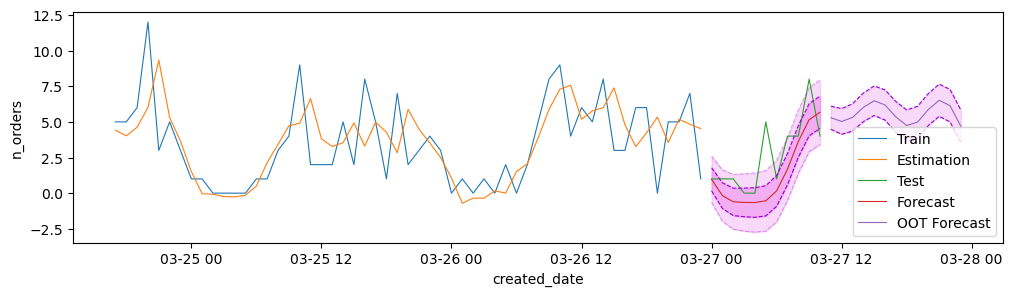

Processing account_id: 457bce7b-9300-4c10-9a97-070b3c0d081d, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 2044.466
train MAE:  1286.139
test RMSE: 4610.872
test MAE:  2403.421


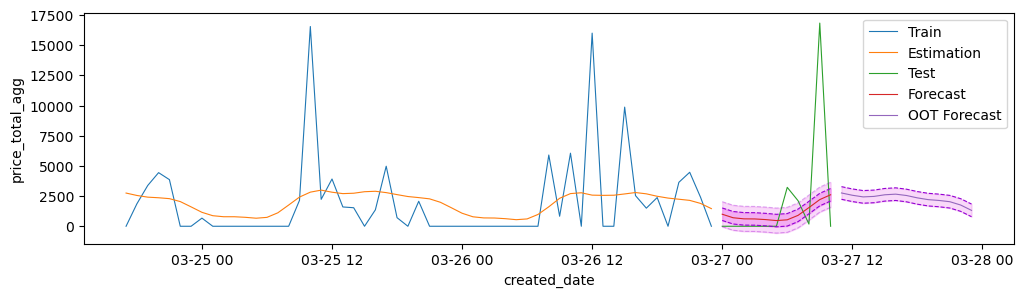

Processing column: n_orders
train RMSE: 0.828
train MAE:  0.573
test RMSE: 0.780
test MAE:  0.606


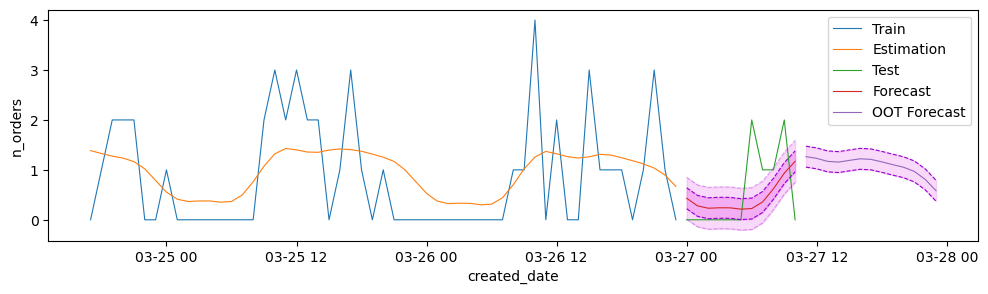

Processing account_id: 173e2b27-8bc6-44d1-b581-a1913d6b1894, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 2506.801
train MAE:  1776.207
test RMSE: 1842.238
test MAE:  1352.519


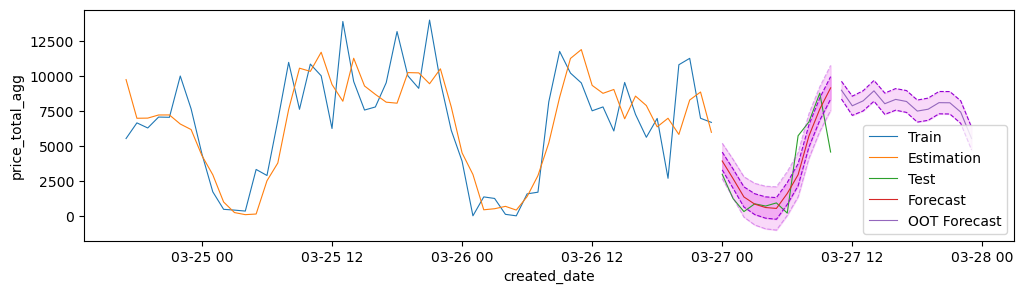

Processing column: n_orders
train RMSE: 5.677
train MAE:  4.003
test RMSE: 3.911
test MAE:  2.171


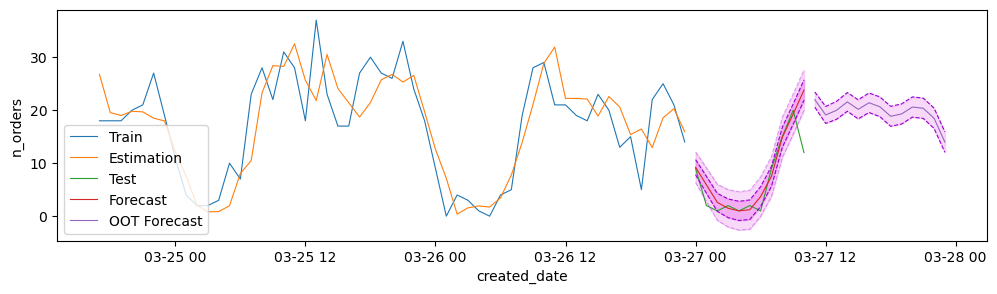

Processing account_id: bfcbb283-4e53-41fd-9b31-aa818f7f23ce, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 1282.422
train MAE:  369.495
test RMSE: 2216.546
test MAE:  2186.476


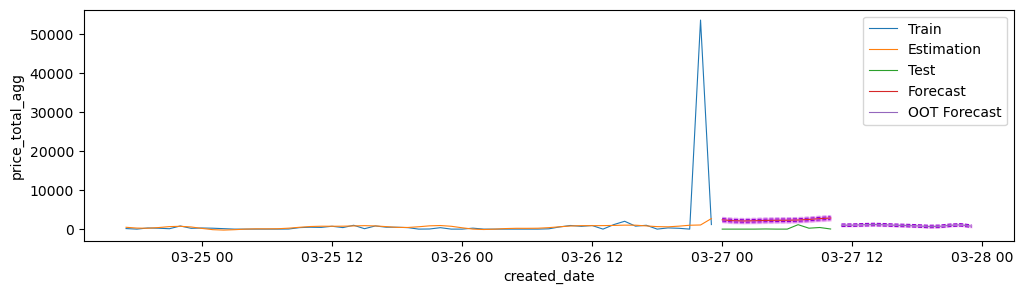

Processing column: n_orders
train RMSE: 1.433
train MAE:  1.006
test RMSE: 1.281
test MAE:  1.045


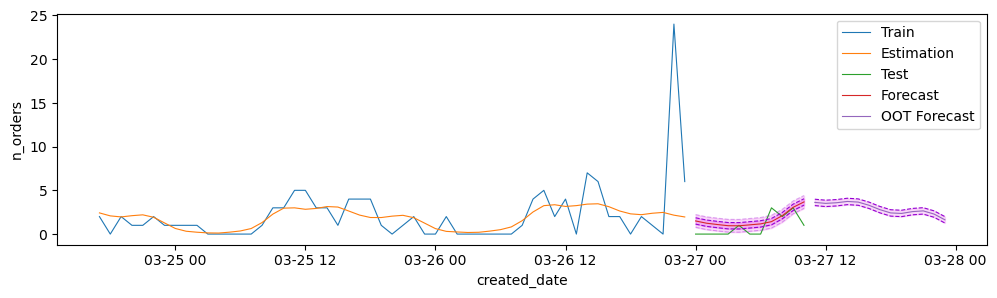

Processing account_id: 0ad2f65b-ee0e-4d50-93e2-84b76282325f, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 4234.784
train MAE:  2917.318
test RMSE: 2412.896
test MAE:  2192.021


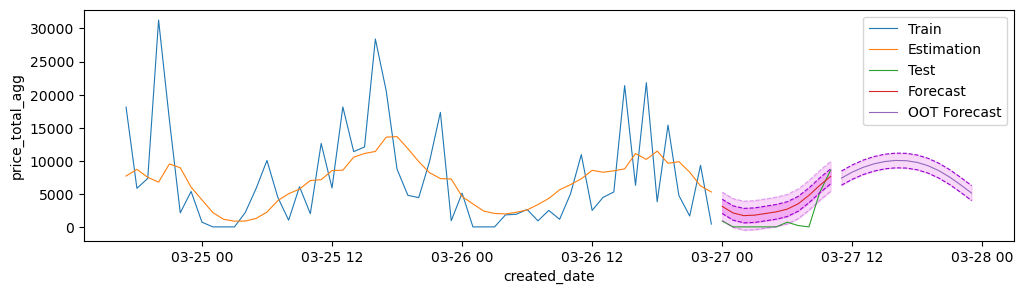

Processing column: n_orders
train RMSE: 2.886
train MAE:  2.046
test RMSE: 1.038
test MAE:  0.723


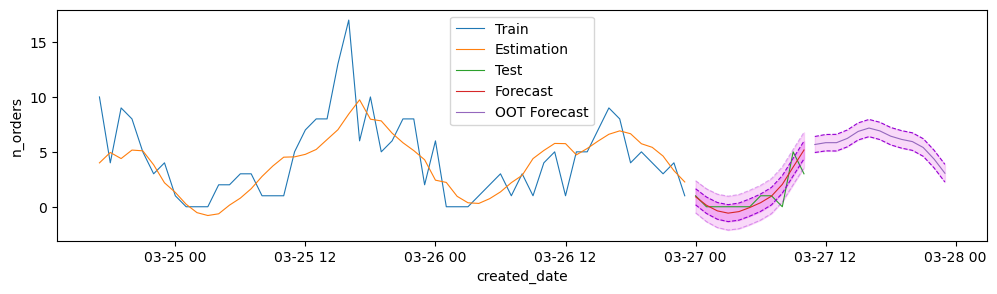

Processing account_id: 60ca8452-5b14-481f-a637-8756f527aee8, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 895.308
train MAE:  219.835
test RMSE: 0.000
test MAE:  0.000


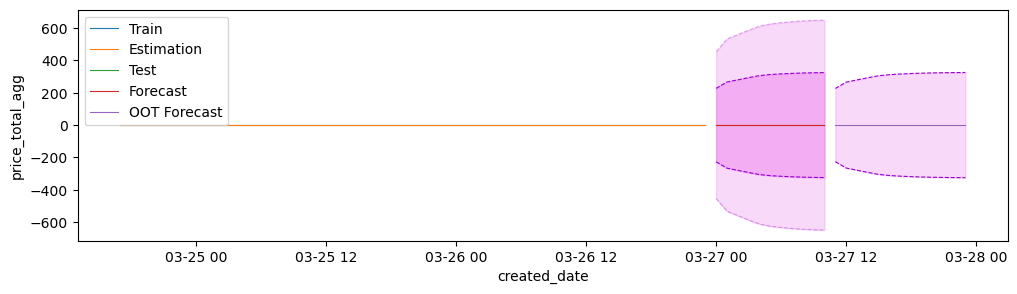

Processing column: n_orders
train RMSE: 4.337
train MAE:  1.106
test RMSE: 0.000
test MAE:  0.000


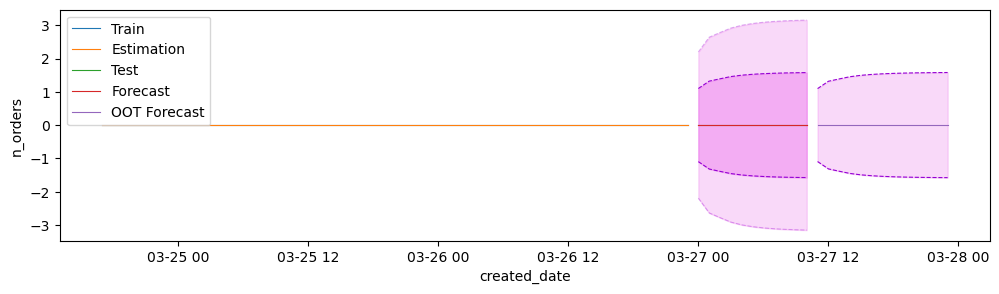

Processing account_id: 9d1296ca-9e4f-4840-b7b5-e12172acab78, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 497.225
train MAE:  248.893
test RMSE: 177.679
test MAE:  159.220


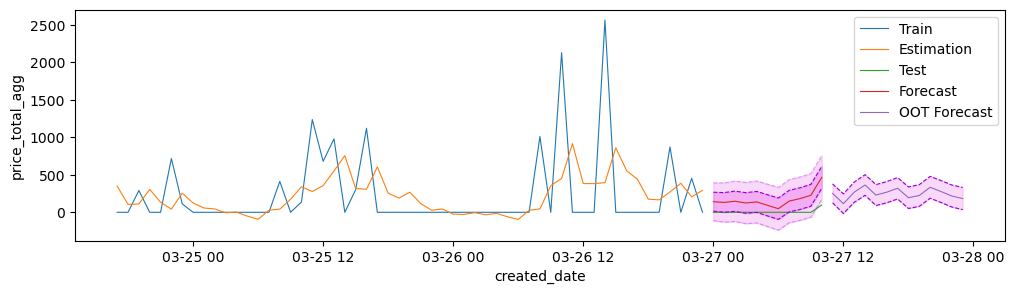

Processing column: n_orders
train RMSE: 1.561
train MAE:  0.750
test RMSE: 0.274
test MAE:  0.214


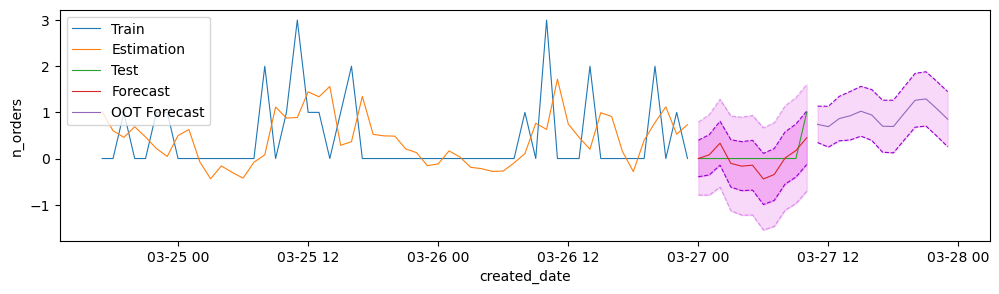

Processing account_id: 6cd2fa8a-5bac-4cc0-b4df-bd2c7d29e71b, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 189.612
train MAE:  134.491
test RMSE: 76.500
test MAE:  58.126


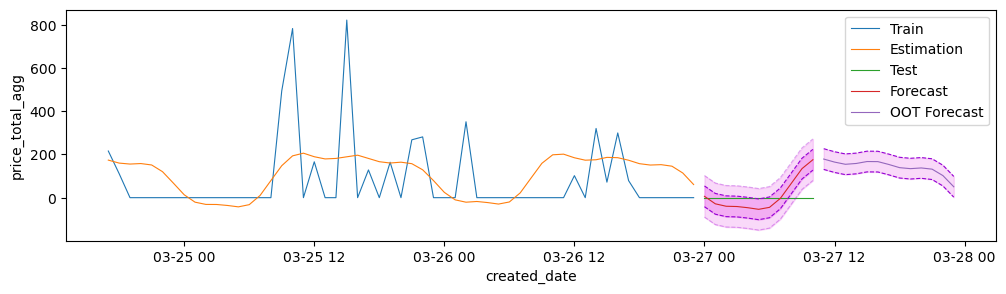

Processing column: n_orders
train RMSE: 0.828
train MAE:  0.580
test RMSE: 0.360
test MAE:  0.305


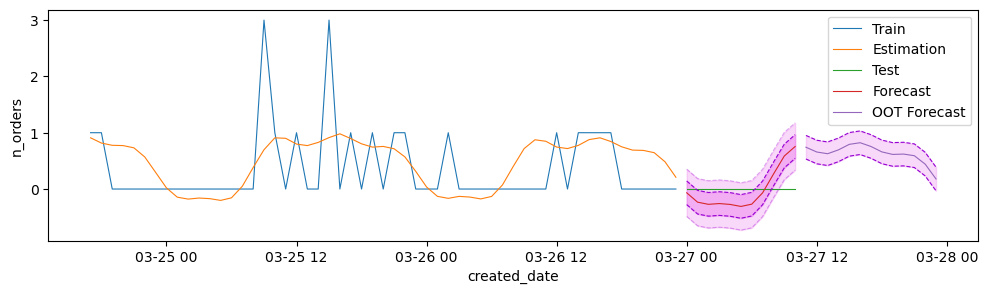

Processing account_id: f4471620-212b-4991-98d3-b498835d0c29, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


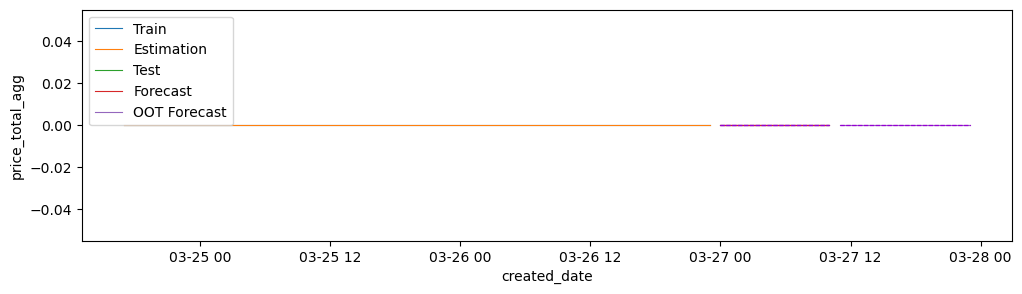

Processing column: n_orders
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


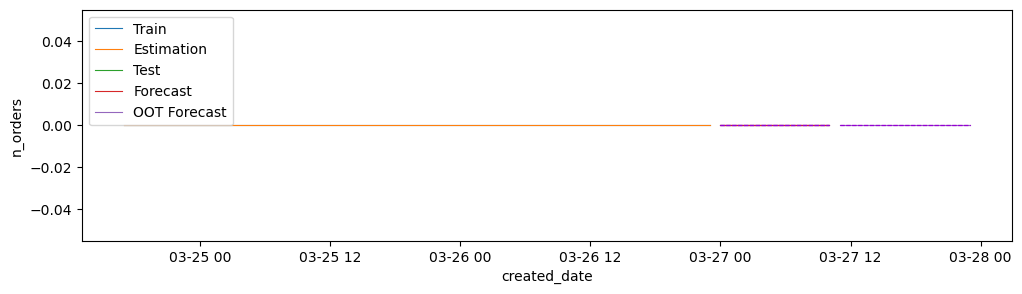

Processing account_id: 6276b87c-ebb2-11ed-a05b-0242ac120003, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 360.742
train MAE:  246.048
test RMSE: 286.529
test MAE:  187.938


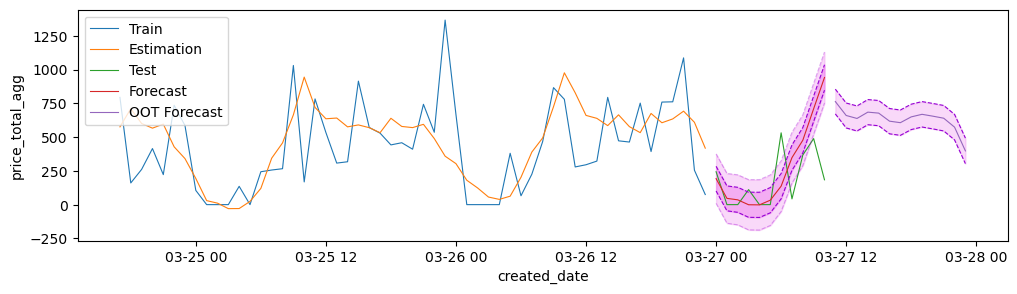

Processing column: n_orders
train RMSE: 2.446
train MAE:  1.736
test RMSE: 1.898
test MAE:  1.216


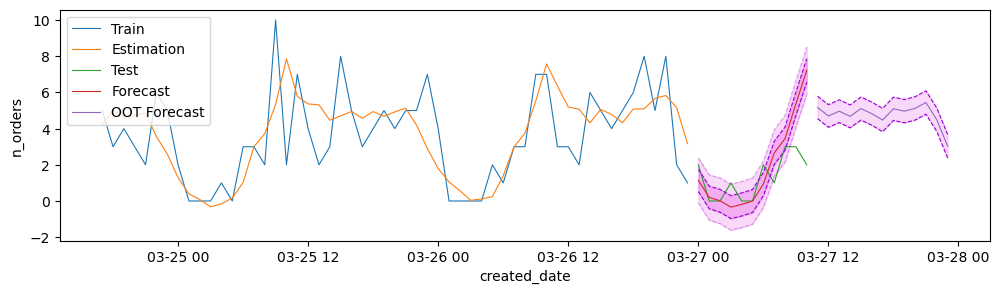

Processing account_id: 7412074f-0f3a-4724-b035-7fb4db3174c8, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 2634.325
train MAE:  795.912
test RMSE: 580.123
test MAE:  389.853


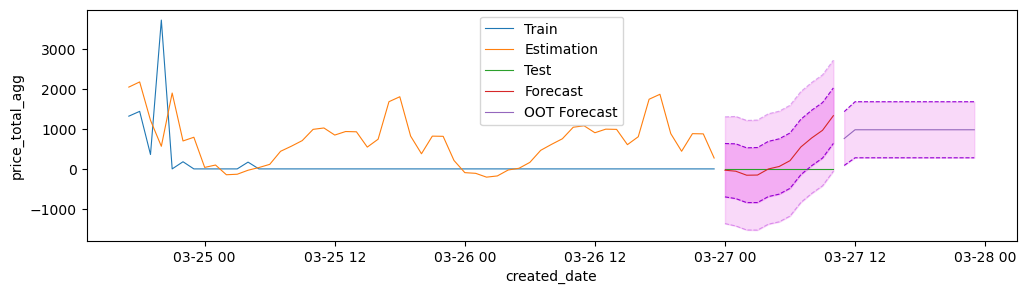

Processing column: n_orders
train RMSE: 3.309
train MAE:  1.394
test RMSE: 1.151
test MAE:  1.017


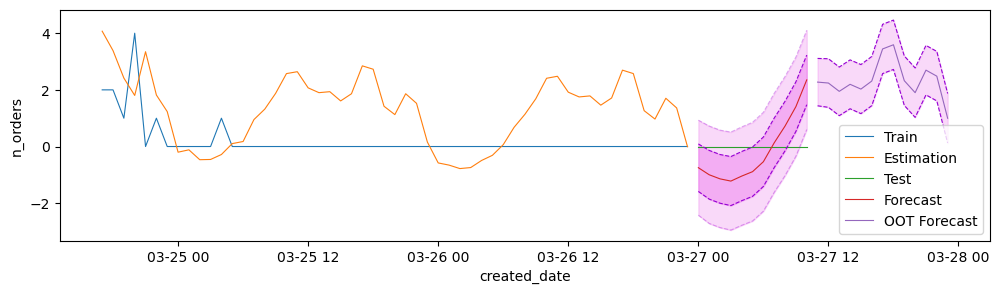

Processing account_id: 0661e926-f219-456e-bde5-612fee6f891c, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 915.796
train MAE:  424.292
test RMSE: 389.431
test MAE:  328.213


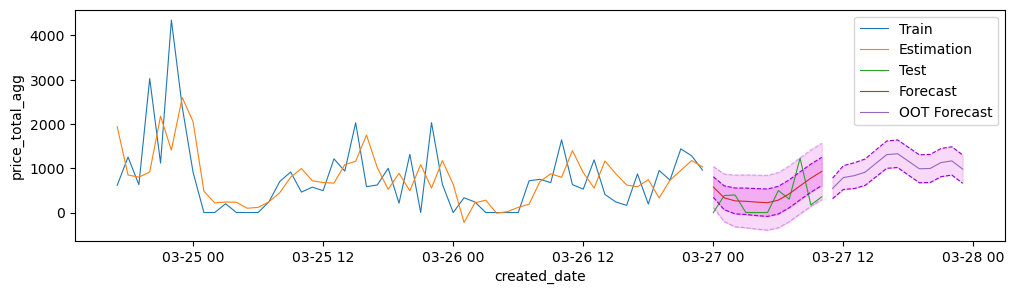

Processing column: n_orders
train RMSE: 6.116
train MAE:  2.041
test RMSE: 1.523
test MAE:  1.363


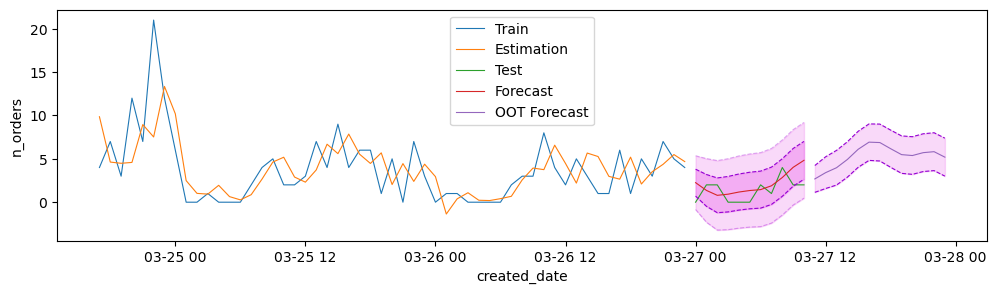

Processing account_id: ad942d1a-15ab-4a0d-83a8-ae82183ece53, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 534.948
train MAE:  374.289
test RMSE: 471.797
test MAE:  386.580


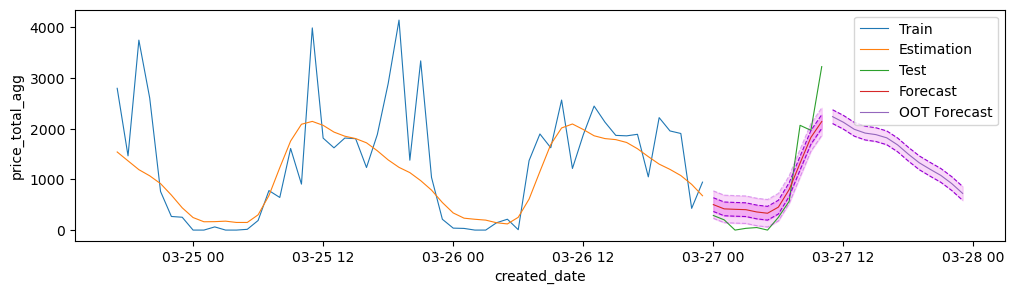

Processing column: n_orders
train RMSE: 2.904
train MAE:  2.143
test RMSE: 1.845
test MAE:  1.392


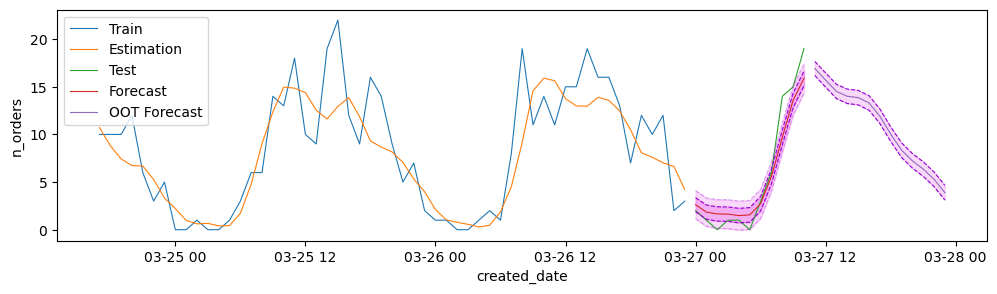

Processing account_id: f9129295-bb08-4330-b60c-9f0beadda521, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 126880.566
train MAE:  83668.742
test RMSE: 69677.692
test MAE:  56884.046


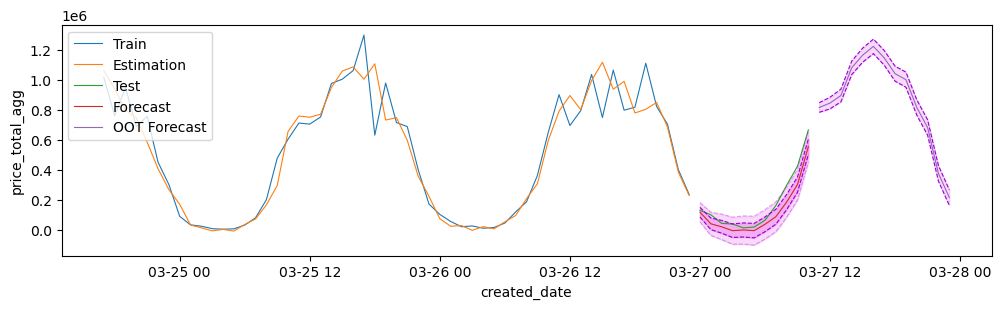

Processing column: n_orders
train RMSE: 32.697
train MAE:  22.535
test RMSE: 16.352
test MAE:  14.462


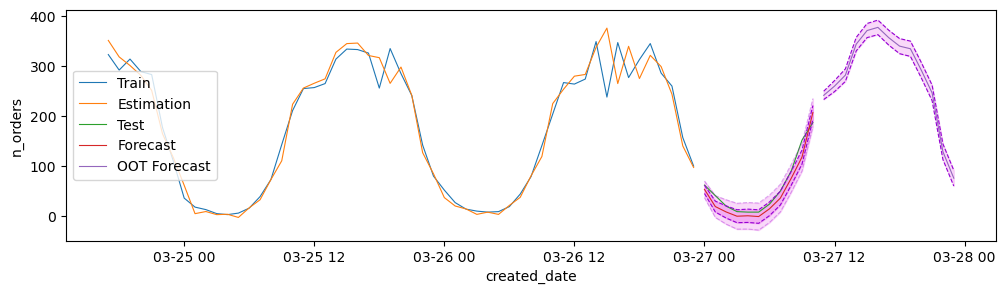

Processing account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


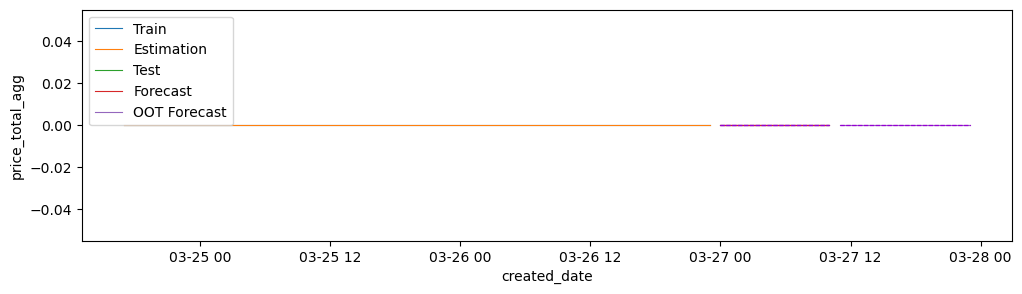

Processing column: n_orders
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


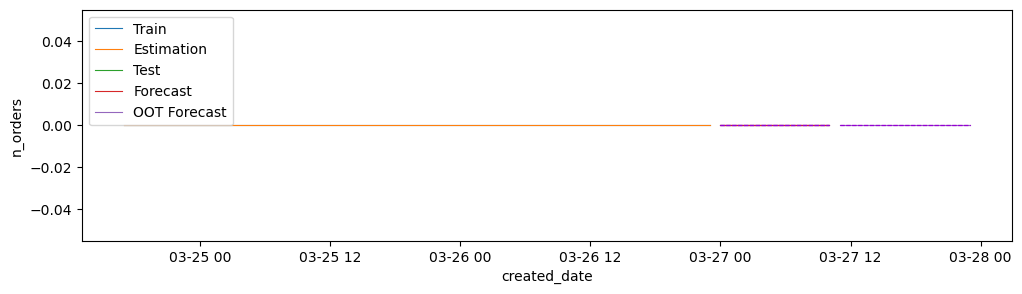

Processing account_id: 60c8f748-e29d-4fce-9e66-584117ca2baf, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 3276.409
train MAE:  2349.038
test RMSE: 4010.964
test MAE:  3531.409


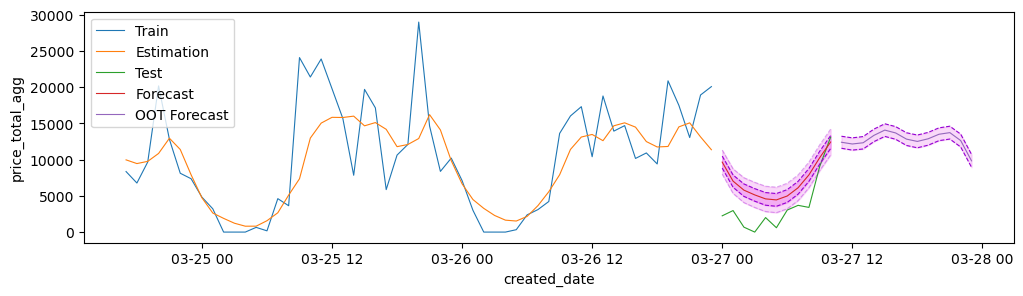

Processing column: n_orders
train RMSE: 6.003
train MAE:  4.499
test RMSE: 6.940
test MAE:  5.990


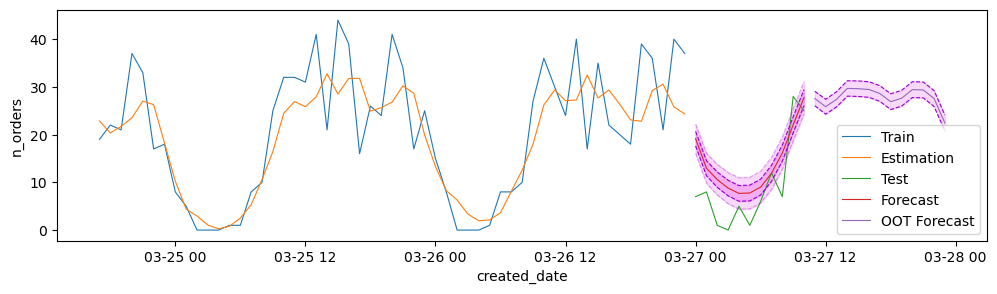

Processing account_id: 2058f680-aace-4b31-aed4-f34397b75096, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 1.297
train MAE:  0.126
test RMSE: 0.047
test MAE:  0.038


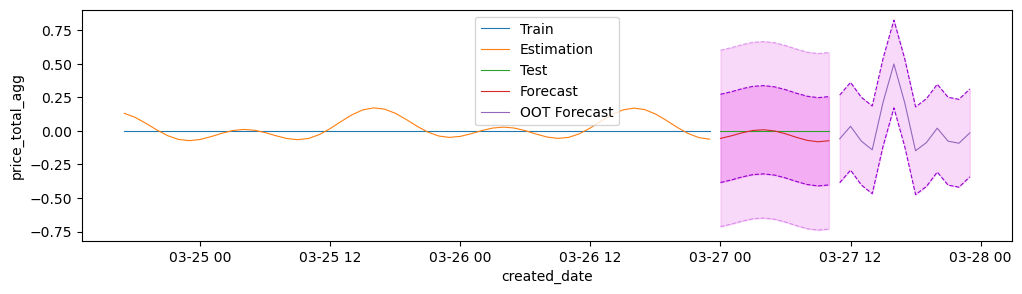

Processing column: n_orders
train RMSE: 0.030
train MAE:  0.003
test RMSE: 0.001
test MAE:  0.001


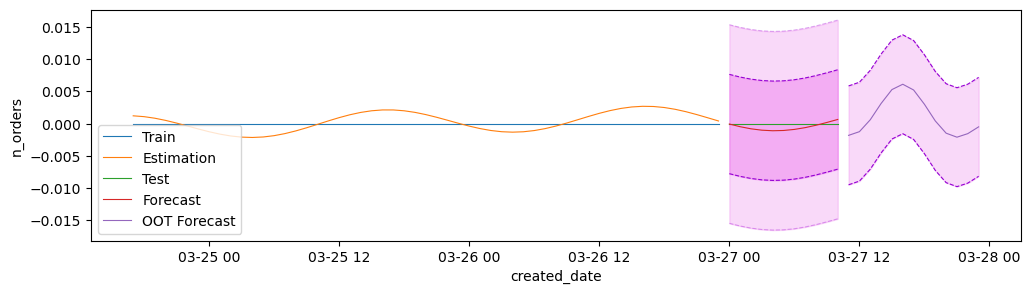

Processing account_id: 5dd8b3ee-6f1c-4ac9-bbc5-91829dde38eb, sales_channel_id: ALL
Processing column: price_total_agg
train RMSE: 2972.251
train MAE:  2053.799
test RMSE: 1438.288
test MAE:  1006.171


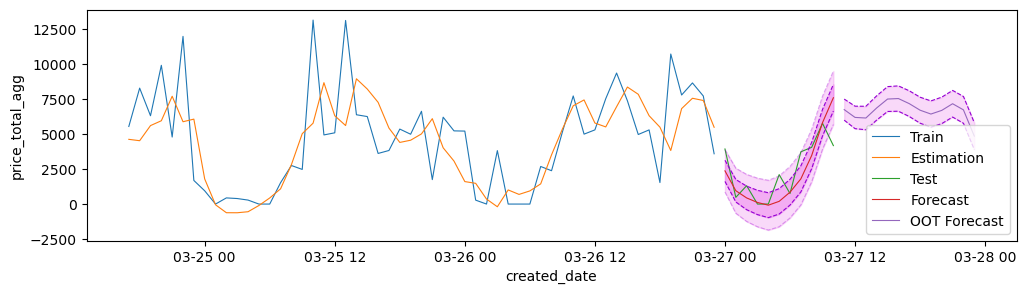

Processing column: n_orders


In [ ]:
def preprocess_sales_data(account_id, sales_channel_id):
    if sales_channel_id == 'ALL':
        cond = (sales['account_id'] == account_id) & \
               (sales['status'].notna())
    else:
        cond = (sales['account_id'] == account_id) & \
               (sales['sales_channel_id'] == sales_channel_id) & \
               (sales['status'].notna())
    df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
    df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
    df_client = df_client.sort_values('created_date').reset_index(drop=True)
    df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

    df_client_mod = df_client.groupby('created_date').agg(
        price_total_agg=('price_total', 'sum'),
        n_orders=('created_date', 'count')
    )
    df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

    end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
    start_date = end_date - relativedelta(months=LOOKBACK)
    date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
    df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    oot_date_index = pd.Series(df_oot.index, name='created_date')
    combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
    df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    return df_client_mod


def create_lagged_features(df, lags=24):
    lagged_features = [df.shift(l).rename(f'lag_{l}') for l in range(1, lags + 1)]
    df_lag = pd.concat([df, pd.concat(lagged_features, axis=1)], axis=1).dropna().asfreq('h')
    return df_lag


def split_data(df_lag):
    df_train = df_lag.loc[df_lag.index < START_DATE].copy()
    df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
    df_oot = df_lag.loc[df_lag.index > END_DATE].copy()
    return df_train, df_test, df_oot


def train_and_forecast(df_train, df_test, df_full, df_oot, col, SEASONAL_PERIODS):
    model = TBATS(sp=SEASONAL_PERIODS, show_warnings=False, n_jobs=-1)
    model.fit(df_train[col])
    
    estimations = model.predict(fh=df_train.index)

    forecast = model.predict(fh=df_test.index)
    forecast_int = model.predict_interval(fh=df_test.index, coverage=COVERAGE)
    forecast_lower, forecast_upper = forecast_int.iloc[:, 0], forecast_int.iloc[:, 1]

    oot_model = TBATS(sp=SEASONAL_PERIODS, show_warnings=False, n_jobs=-1)
    oot_model.fit(df_full[col])

    oot_forecast = oot_model.predict(fh=df_oot.index)
    oot_forecast_int = oot_model.predict_interval(fh=df_oot.index, coverage=COVERAGE)
    oot_forecast_lower, oot_forecast_upper = oot_forecast_int.iloc[:, 0], oot_forecast_int.iloc[:, 1]

    return {
        'estimations': estimations,
        'forecast': forecast,
        'forecast_lower': forecast_lower,
        'forecast_upper': forecast_upper,
        'oot_forecast': oot_forecast,
        'oot_forecast_lower': oot_forecast_lower,
        'oot_forecast_upper': oot_forecast_upper
    }
    
    
def compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col):
    y_train = df_train[col]
    y_test = df_test[col]
    estimations = forecast_results['estimations']
    forecast = forecast_results['forecast']
    forecast_lower = forecast_results['forecast_lower']
    forecast_upper = forecast_results['forecast_upper']
    oot_forecast = forecast_results['oot_forecast']
    oot_forecast_lower = forecast_results['oot_forecast_lower']
    oot_forecast_upper = forecast_results['oot_forecast_upper']
    
    train_mae = mean_absolute_error(df_train[col], estimations)
    train_rmse = root_mean_squared_error(df_train[col], estimations)
    print(f"train RMSE: {train_rmse:.3f}")
    print(f"train MAE:  {train_mae:.3f}")
    test_mae = mean_absolute_error(df_test[col], forecast)
    test_rmse = root_mean_squared_error(df_test[col], forecast)
    print(f"test RMSE: {test_rmse:.3f}")
    print(f"test MAE:  {test_mae:.3f}")
    
    plt.figure(figsize=(12, 3))
    sns.lineplot(y_train.iloc[-5*TEST_SIZE:], lw=0.8, label='Train')
    sns.lineplot(estimations.iloc[-5*TEST_SIZE:], lw=0.8, label='Estimation')
    sns.lineplot(y_test, lw=0.8, label='Test')
    sns.lineplot(forecast, lw=0.8, label='Forecast')
    sns.lineplot(forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
    sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    plt.fill_between(x=forecast.index,
                     y1=forecast_lower,
                     y2=forecast_upper,
                     color='violet',
                     alpha=0.5)
    plt.fill_between(x=forecast.index,
                     y1=2*forecast_lower-forecast,
                     y2=2*forecast_upper-forecast,
                     color='violet',
                     alpha=0.3)
    plt.fill_between(x=oot_forecast.index,
                     y1=oot_forecast_lower,
                     y2=oot_forecast_upper,
                     color='violet',
                     alpha=0.3)
    plt.legend()
    plt.show()
    
    return train_rmse, test_rmse, train_mae, test_mae


def save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict):
    with open(f'sql/time_series/forecast_{account_id}_{sales_channel_id}_ts.sql', 'w') as output_file:
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['forecast'].iloc[i]});
                """
            )
        for i in range(len(df_oot)):
            start_time = df_oot.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast'].iloc[i]});
                """
            )


# Main
if ALL_SALES_CHANNELS:
    id_pairs = set(list(zip(df_count['account_id'], ['ALL']*len(df_count))))
else:
    id_pairs = list(zip(df_count['account_id'], df_count['sales_channel_id']))

summary_dict = {}
for account_id, sales_channel_id in id_pairs:
    print(f'Processing account_id: {account_id}, sales_channel_id: {sales_channel_id}')
    summary_dict[(account_id, sales_channel_id)] = {}

    df_client_mod = preprocess_sales_data(account_id, sales_channel_id)
    df_client_mod.fillna(0, inplace=True)

    forecast_dict = {}
    for n, col in enumerate(['price_total_agg', 'n_orders']):
        print(f'Processing column: {col}')
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {'name': col}

        df_lag = create_lagged_features(df_client_mod[col])
        df_train, df_test, df_oot = split_data(df_lag)
        df_full = pd.concat([df_train, df_test], axis=0)

        forecast_results = train_and_forecast(df_train, df_test, df_full, df_oot, col, SEASONAL_PERIODS)

        forecast_dict[f'dataset_{n}'] = {}
        forecast_dict[f'dataset_{n}'].update(forecast_results)
        
        train_rmse, test_rmse, train_mae, test_mae = compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col)
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae

    save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict)

In [ ]:
dataset_0 = pd.DataFrame({k: v['dataset_0'] for k, v in summary_dict.items()}).T
dataset_1 = pd.DataFrame({k: v['dataset_1'] for k, v in summary_dict.items()}).T

In [ ]:
summary = (
    pd
    .concat([dataset_0, dataset_1], axis=0)
    .rename({'name': 'dataset'}, axis=1)
    .sort_index()
    .reset_index(names=['account_id', 'sales_channel_id'])
)
summary.to_csv('summary_ts.csv', sep=';')

summary

In [ ]:
train_metrics = summary.groupby('dataset')['train MAE'].mean()

train_metrics

In [ ]:
test_metrics = summary.groupby('dataset')['test MAE'].mean()

test_metrics

In [ ]:
(train_metrics - test_metrics).abs()